## Analyse Classification performance

0. Annotate data sample of 870 rels by file (~50 per goal)

1. **Metric vs. Manual annotation** (overall and by goal):
    - Recall
    - Precision
    - Accuracy
    - F1-score
    - Coverage Ratio: ( of distinct reference arguments covered) ÷ (total reference arguments).
    - Overgeneration: (# retrieved – # matched) ÷ (# retrieved).





In [ ]:
import os
import pandas as pd

def csv_length_range(directory, prefix):
    lengths = []
    dic_info = {}
    total_length = 0

    for file in os.listdir(directory):
        if file.endswith(".csv") and file.startswith(prefix):
            filepath = os.path.join(directory, file)
            try:
                # count rows 
                with open(filepath, "r", encoding="utf-8") as f:
                    row_count = sum(1 for _ in f) - 1 
                lengths.append(row_count)
                dic_info[file] = row_count
                total_length += row_count

            except Exception as e:
                print(f"Error reading {file}: {e}")

    if not lengths:
        print("No matching CSV files found.")
        return 

    print(f"Range: {min(lengths)} to {max(lengths)}, total relationships {total_length}")
    print(f"Details: {dic_info}")

print('Relationships with Keywords')
dic_cross = csv_length_range("..\\Data\\Relationships Keywords", "cross_goal")
dic_intra = csv_length_range("..\\Data\\Relationships Keywords", "intra_goal")

print('\nRelationships without Keywords')
dic_cross = csv_length_range("..\\Data\\Relationships No Keywords", "cross_goal")
dic_intra = csv_length_range("..\\Data\\Relationships No Keywords", "intra_goal")

72252 + 831204 + 793123 + 77588

Relationships with Keywords
Range: 12 to 142782, total relationships 831204
Details: {'cross_goalG20_2024_deepseek-r1-70b.csv': 749, 'cross_goalG20_2024_gemma3-27b.csv': 638, 'cross_goalG20_2024_gemma3-4b.csv': 675, 'cross_goalG20_2024_llama3.3-70b.csv': 709, 'cross_goalG20_2024_qwen2.5-3b.csv': 12, 'cross_goalGLOBAL_SGD2023_deepseek-r1-70b.csv': 60991, 'cross_goalGLOBAL_SGD2023_gemma3-27b.csv': 36832, 'cross_goalGLOBAL_SGD2023_gemma3-4b.csv': 71234, 'cross_goalGLOBAL_SGD2023_llama3.3-70b.csv': 58310, 'cross_goalGLOBAL_SGD2023_qwen2.5-3b.csv': 4050, 'cross_goalGLOBAL_SGD2024_deepseek-r1-70b.csv': 142409, 'cross_goalGLOBAL_SGD2024_gemma3-27b.csv': 61351, 'cross_goalGLOBAL_SGD2024_gemma3-4b.csv': 105958, 'cross_goalGLOBAL_SGD2024_llama3.3-70b.csv': 142782, 'cross_goalGLOBAL_SGD2024_qwen2.5-3b.csv': 965, 'cross_goalGLOBAL_SGD2025_deepseek-r1-70b.csv': 18212, 'cross_goalGLOBAL_SGD2025_gemma3-27b.csv': 10349, 'cross_goalGLOBAL_SGD2025_gemma3-4b.csv': 21281, 'cross_goalGLOBAL_SGD2025_llama3.

In [1]:
import os, re, random, sys, glob
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, cohen_kappa_score
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

## Relationships sampling and annotations

1) For each goal g, choose up to 'target_per_goal' distinct arg1 (id_arg1) of that goal.
2) For each other goal h != g, pick one row that matches (g->h) and that arg1 (if any), else any row (g->h).
3) Top up randomly (no duplicates) to reach 'target_total' if possible.

### Cross goal

In [5]:
LABEL_MAP = {
    "s": "Support",
    "a": "Attack",
    "r": "Rephrase",
    "n": "No Relationship",
}
VALID_KEYS = set(LABEL_MAP.keys())

def parse_goal(id_str):
    try:
        return int(str(id_str).split("_", 1)[0])
    except Exception:
        return None

def _select_pool_cross_goal(df, seed=42, target_per_goal=5, target_total=1500):
    rng = random.Random(seed)

    # add helper columns once
    if "g1" not in df.columns or "g2" not in df.columns:
        df = df.copy()
        df["g1"] = df["id_arg1"].apply(parse_goal)
        df["g2"] = df["id_arg2"].apply(parse_goal)

    # universe of goals seen in the file (usually 0..17)
    goals = sorted(set(df["g1"].dropna().astype(int).unique().tolist()))
    picked_idx = []

    # fast lookup by (g1,g2)
    by_pair = {(g1, g2): sub.index.to_list()
               for (g1, g2), sub in df.groupby(["g1", "g2"], dropna=False)}

    for g in goals:
        # distinct arg1 inside goal g
        arg1s_g = df.loc[df["g1"] == g, "id_arg1"].dropna().astype(str).unique().tolist()
        rng.shuffle(arg1s_g)
        chosen_arg1s = arg1s_g[:target_per_goal] if len(arg1s_g) >= target_per_goal else arg1s_g

        for a1 in chosen_arg1s:
            for h in goals:
                if h == g:
                    continue
                # prefer rows with this specific arg1 vs goal h
                mask = (df["g1"] == g) & (df["g2"] == h) & (df["id_arg1"].astype(str) == a1)
                rows = df[mask].index.to_list()
                if not rows:
                    # fallback: any row for (g->h)
                    rows = by_pair.get((g, h), [])
                if rows:
                    picked_idx.append(rng.choice(rows))

    # de-duplicate while preserving order
    seen = set()
    ordered = []
    for i in picked_idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)

    # top up to target_total if needed
    if len(ordered) < target_total:
        remaining = [i for i in df.index if i not in seen]
        rng.shuffle(remaining)
        ordered.extend(remaining[:max(0, target_total - len(ordered))])

    return df.loc[ordered].copy()

def parse_goal(id_str):
    # id format: "<goal>_<index>"
    try:
        return int(str(id_str).split("_", 1)[0])
    except Exception:
        return None

def sample_and_annotate_cross_goal(
    input_dir,
    output_dir,
    filename,
    seed=42,
    target_per_goal=5,
    target_total=1500,
    autosave_every=50,
):
    os.makedirs(output_dir, exist_ok=True)

    path = os.path.join(input_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    # read raw file (allow empty strings, not NaN)
    df = pd.read_csv(path, keep_default_na=False)
    required = {"SDGarg1", "SDGarg2", "id_arg1", "id_arg2", "rel"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    base, ext = os.path.splitext(filename)
    out_sample = os.path.join(output_dir, f"{base}_sample{ext}")

    # resume or create sample
    if os.path.exists(out_sample):
        print(f"Resuming from sampled file: {out_sample}")
        sampled = pd.read_csv(out_sample, keep_default_na=False)
    else:
        sampled = _select_pool_cross_goal(df, seed=seed,
                                          target_per_goal=target_per_goal,
                                          target_total=target_total)
        if "rel" not in sampled.columns:
            sampled["rel"] = ""
        else:
            sampled["rel"] = sampled["rel"].fillna("")  # ensure blanks are blanks
        sampled.to_csv(out_sample, index=False, encoding="utf-8")
        print(f"Sample saved: {out_sample} (rows={len(sampled)})")

    print("\nAnnotation controls:")
    print("  Type S/A/R/N → Support/Attack/Rephrase/No Relationship")
    print("  Enter to skip, 'b' to go back, 'q' to save & quit.\n")

    # find first unlabeled row (treat NaN and empty as unlabeled)
    sampled["rel"] = sampled["rel"].astype(str)
    mask_unlabeled = sampled["rel"].isna() | (sampled["rel"].str.strip().isin({"", "nan", "None"}))
    unlabeled_idx = sampled.index[mask_unlabeled].tolist()
    if unlabeled_idx:
        i = sampled.index.get_loc(unlabeled_idx[0])
    else:
        print("All sampled rows already labeled.")
        return out_sample

    labeled_since_save = 0
    while 0 <= i < len(sampled):
        row = sampled.iloc[i]
        a1 = str(row["SDGarg1"])
        a2 = str(row["SDGarg2"])
        print(f"\n[{i+1}/{len(sampled)}]  G1={parse_goal(row['id_arg1'])}  G2={parse_goal(row['id_arg2'])}")
        print("Arg1:", a1)
        print("Arg2:", a2)
        prev = str(row.get("rel", "")).strip()
        if prev and prev.lower() not in {"nan", "none"}:
            print(f"(already labeled: {prev})")

        key = input("Label [S/A/R/N, Enter=skip, b=back, q=quit] > ").strip().lower()

        if key == "q":
            sampled.to_csv(out_sample, index=False, encoding="utf-8")
            print(f"\nSaved & quit: {out_sample}")
            return out_sample
        if key == "b":
            i = max(0, i - 1)
            continue
        if key == "":
            i += 1
            continue

        if key in VALID_KEYS:
            sampled.iat[i, sampled.columns.get_loc("rel")] = LABEL_MAP[key]
            labeled_since_save += 1
        else:
            print("Invalid key. Use S/A/R/N, Enter, b, or q.")
            continue

        if labeled_since_save >= autosave_every:
            sampled.to_csv(out_sample, index=False, encoding="utf-8")
            print(f"(autosaved {autosave_every} labels) -> {out_sample}")
            labeled_since_save = 0

        i += 1

    sampled.to_csv(out_sample, index=False, encoding="utf-8")
    print(f"\nDone. Saved: {out_sample}")
    return out_sample

In [6]:
input_dir = r"..\\Data\\Relationships Keywords"
prefix = 'GLOBAL_SGD2023_'

file_names = []
for file in glob.glob(os.path.join(input_dir, "*cross_goal*.csv")):
    if prefix in file.split("\\")[-1]:
        file_names.append(file.split("\\")[-1])
print(file_names)

['cross_goalGLOBAL_SGD2023_deepseek-r1-70b.csv', 'cross_goalGLOBAL_SGD2023_gemma3-27b.csv', 'cross_goalGLOBAL_SGD2023_gemma3-4b.csv', 'cross_goalGLOBAL_SGD2023_llama3.3-70b.csv', 'cross_goalGLOBAL_SGD2023_qwen2.5-3b.csv']


In [ ]:
input_dir = r"..\\Data\\Relationships Keywords"
output_dir = r"..\\Data\\Relationships Keywords\\Annotated"
prefix = 'GLOBAL_SGD2023_'

file_names = ['cross_goalGLOBAL_SGD2023_deepseek-r1-70b.csv', 
              'cross_goalGLOBAL_SGD2023_gemma3-27b.csv']

for document in file_names:
    sample_and_annotate_cross_goal(
        input_dir,
        output_dir,
        document,
        seed=42,
        target_per_goal=3,
        target_total=870,
        autosave_every=50)

Sample saved: ..\\Data\\Relationships Keywords\\Annotated\cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sample.csv (rows=870)

Annotation controls:
  Type S/A/R/N → Support/Attack/Rephrase/No Relationship
  Enter to skip, 'b' to go back, 'q' to save & quit.


[1/870]  G1=0  G2=1
Arg1: We conclude by underscoring the vital, life-affirming importance of four key international agreements: the Sustainable Development Goals, the Paris Climate Agreement, the Kunming-Montreal Framework for Biodiversity, and the High Seas Treaty.
Arg2: Space-based technologies help address data gaps and timeliness, including supporting the 'leave no one behind' principle;

[2/870]  G1=0  G2=2
Arg1: We conclude by underscoring the vital, life-affirming importance of four key international agreements: the Sustainable Development Goals, the Paris Climate Agreement, the Kunming-Montreal Framework for Biodiversity, and the High Seas Treaty.
Arg2: 4. Sustainable ecosystems, sustainable agriculture, and climate resilience

### Intra-goal 

In [3]:
def _select_pool_intra_goal(
    df,
    seed=42,
    target_per_goal=25,          
    per_arg1_limit=1,            
    target_total=1500,
):
    rng = random.Random(seed)

    # add helper columns once
    if "g1" not in df.columns or "g2" not in df.columns:
        df = df.copy()
        df["g1"] = df["id_arg1"].apply(parse_goal)
        df["g2"] = df["id_arg2"].apply(parse_goal)

    # only rows where both args are from the same goal
    intra = df[(df["g1"].notna()) & (df["g2"].notna()) & (df["g1"] == df["g2"])].copy()
    intra["g1"] = intra["g1"].astype(int)
    goals = sorted(intra["g1"].unique().tolist())

    picked_idx = []

    # fast lookup: for each goal, group rows by arg1 within that goal
    by_goal_arg1 = {}
    for (g, a1), sub in intra.groupby(["g1", "id_arg1"], dropna=False):
        by_goal_arg1[(g, str(a1))] = sub.index.to_list()

    by_goal_any = {g: sub.index.to_list() for g, sub in intra.groupby("g1", dropna=False)}

    for g in goals:
        # distinct arg1 inside goal g
        arg1s_g = (
            intra.loc[intra["g1"] == g, "id_arg1"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        rng.shuffle(arg1s_g)
        chosen_arg1s = arg1s_g[:target_per_goal] if len(arg1s_g) >= target_per_goal else arg1s_g

        for a1 in chosen_arg1s:
            # all intra-goal rows where this is the left argument
            rows = by_goal_arg1.get((g, a1), [])
            if rows:
                rng.shuffle(rows)
                take = rows[:per_arg1_limit] if per_arg1_limit else rows
                picked_idx.extend(take)
            else:
                pool = by_goal_any.get(g, [])
                if pool:
                    picked_idx.append(rng.choice(pool))

    # de-duplicate while preserving order
    seen = set()
    ordered = []
    for i in picked_idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)

    if len(ordered) < target_total:
        remaining = [i for i in intra.index if i not in seen]
        rng.shuffle(remaining)
        ordered.extend(remaining[:max(0, target_total - len(ordered))])

    return df.loc[ordered].copy()

def sample_and_annotate_intra_goal(
    input_dir,
    output_dir,
    filename,
    seed=42,
    target_per_goal=25,     
    per_arg1_limit=1,        
    target_total=1500,
    autosave_every=50):

    os.makedirs(output_dir, exist_ok=True)

    path = os.path.join(input_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    # read raw file (allow empty strings, not NaN)
    df = pd.read_csv(path, keep_default_na=False)
    required = {"SDGarg1", "SDGarg2", "id_arg1", "id_arg2", "rel"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    base, ext = os.path.splitext(filename)
    out_sample = os.path.join(output_dir, f"{base}_intra_sample{ext}")

    # resume or create sample
    if os.path.exists(out_sample):
        print(f"Resuming from sampled file: {out_sample}")
        sampled = pd.read_csv(out_sample, keep_default_na=False)
    else:
        sampled = _select_pool_intra_goal(
            df,
            seed=seed,
            target_per_goal=target_per_goal,
            per_arg1_limit=per_arg1_limit,
            target_total=target_total,
        )
        if "rel" not in sampled.columns:
            sampled["rel"] = ""
        else:
            sampled["rel"] = sampled["rel"].fillna("")
        sampled.to_csv(out_sample, index=False, encoding="utf-8")
        print(f"Sample saved: {out_sample} (rows={len(sampled)})")

    print("\nAnnotation controls:")
    print("  Type S/A/R/N → Support/Attack/Rephrase/No Relationship")
    print("  Enter to skip, 'b' to go back, 'q' to save & quit.\n")

    sampled["rel"] = sampled["rel"].astype(str)
    mask_unlabeled = sampled["rel"].isna() | (sampled["rel"].str.strip().isin({"", "nan", "None"}))
    unlabeled_idx = sampled.index[mask_unlabeled].tolist()
    if unlabeled_idx:
        i = sampled.index.get_loc(unlabeled_idx[0])
    else:
        print("All sampled rows already labeled.")
        return out_sample

    labeled_since_save = 0
    while 0 <= i < len(sampled):
        row = sampled.iloc[i]
        a1 = str(row["SDGarg1"])
        a2 = str(row["SDGarg2"])
        g_left = parse_goal(row["id_arg1"])
        g_right = parse_goal(row["id_arg2"])
        print(f"\n[{i+1}/{len(sampled)}]  G={g_left}  (g1==g2? {g_left == g_right})")
        print("Arg1:", a1)
        print("Arg2:", a2)
        prev = str(row.get("rel", "")).strip()
        if prev and prev.lower() not in {"nan", "none"}:
            print(f"(already labeled: {prev})")

        key = input("Label [S/A/R/N, Enter=skip, b=back, q=quit] > ").strip().lower()

        if key == "q":
            sampled.to_csv(out_sample, index=False, encoding="utf-8")
            print(f"\nSaved & quit: {out_sample}")
            return out_sample
        if key == "b":
            i = max(0, i - 1)
            continue
        if key == "":
            i += 1
            continue

        if key in VALID_KEYS:
            sampled.iat[i, sampled.columns.get_loc("rel")] = LABEL_MAP[key]
            labeled_since_save += 1
        else:
            print("Invalid key. Use S/A/R/N, Enter, b, or q.")
            continue

        if labeled_since_save >= autosave_every:
            sampled.to_csv(out_sample, index=False, encoding="utf-8")
            print(f"(autosaved {autosave_every} labels) -> {out_sample}")
            labeled_since_save = 0

        i += 1

    sampled.to_csv(out_sample, index=False, encoding="utf-8")
    print(f"\nDone. Saved: {out_sample}")
    return out_sample

In [6]:
input_dir = r"..\\Data\\Relationships Keywords"
output_dir = r"..\\Data\\Relationships Keywords\\Annotated"
prefix = 'GLOBAL_SGD2023_'

file_names = ['intra_goalGLOBAL_SGD2023_deepseek-r1-70b.csv', 
              'intra_goalGLOBAL_SGD2023_gemma3-27b.csv']

for document in file_names:
    sample_and_annotate_intra_goal(
        input_dir,
        output_dir,
        document,
        seed=42,
        target_per_goal=25,
        per_arg1_limit=1, 
        target_total=425)

Sample saved: ..\\Data\\Relationships Keywords\\Annotated\intra_goalGLOBAL_SGD2023_deepseek-r1-70b_intra_sample.csv (rows=425)

Annotation controls:
  Type S/A/R/N → Support/Attack/Rephrase/No Relationship
  Enter to skip, 'b' to go back, 'q' to save & quit.


[1/425]  G=0  (g1==g2? True)
Arg1: The SDG policy agenda is complex. The SDGs call for lasting, long-term, directed change.
Arg2: The EU Green Deal has great potential to bring about transformation both within the EU and beyond, including the larger European and Mediterranean region, and even Africa.

[2/425]  G=0  (g1==g2? True)
Arg1: At the mid-point of the SDG agenda, we are far off target. Yet we have gained ground.
Arg2: Nation-states continue to hold the primary responsibility for achieving the SDGs.

[3/425]  G=0  (g1==g2? True)
Arg1: Virtually all governments of the world have embraced the SDGs in principle.
Arg2: The contribution of the SDGs towards a universally accepted framework for monitoring progress is critical.

[

In [ ]:
input_dir = r"..\\Data\\Relationships Keywords"
output_dir = r"..\\Data\\Relationships Keywords\\Annotated"
prefix = 'GLOBAL_SGD2024_'

file_names = ['intra_goalGLOBAL_SGD2024_deepseek-r1-70b.csv', 
              'intra_goalGLOBAL_SGD2024_gemma3-27b.csv']

for document in file_names:
    sample_and_annotate_intra_goal(
        input_dir,
        output_dir,
        document,
        seed=42,
        target_per_goal=25,
        per_arg1_limit=1, 
        target_total=425)

In [8]:
import os
import random
import pandas as pd

REQUIRED_GOALS = list(range(18))  # SDG 0..17

# ----------------- helpers -----------------
def parse_goal(id_str):
    """id format: '<goal>_<index>' -> int(goal) or None."""
    try:
        return int(str(id_str).split("_", 1)[0])
    except Exception:
        return None

def _ensure_goals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "g1" not in df.columns: df["g1"] = df["id_arg1"].apply(parse_goal)
    if "g2" not in df.columns: df["g2"] = df["id_arg2"].apply(parse_goal)
    return df

def _verify_and_topup_coverage(sampled: pd.DataFrame, pool: pd.DataFrame, required_goals, *, cross: bool, rng: random.Random):
    """
    Ensure every goal in required_goals appears at least once as g1 in 'sampled'.
    If missing and exists in pool, top up by adding one random row with that g1.
    If still missing (no rows in pool), raise ValueError listing missing goals.
    """
    present = set(sampled["g1"].dropna().astype(int).unique().tolist())
    missing = [g for g in required_goals if g not in present]
    if not missing:
        return sampled

    # try to top up from pool
    additions = []
    for g in missing:
        cand = pool[pool["g1"] == g]
        if cross:
            cand = cand[cand["g2"] != g]  # ensure cross-goal
        if not cand.empty:
            additions.append(cand.sample(n=1, random_state=rng.randint(0, 10**9)))
    if additions:
        sampled = pd.concat([sampled] + additions, axis=0, ignore_index=False).drop_duplicates()

    # re-check
    present = set(sampled["g1"].dropna().astype(int).unique().tolist())
    missing = [g for g in required_goals if g not in present]
    if missing:
        raise ValueError(f"Coverage check failed: no rows for SDG(s) {missing} in the source data.")
    return sampled

# ----------------- CROSS-GOAL sampler (g1 != g2) -----------------
def _select_pool_cross_goal(df, seed=42, target_per_goal=5, target_total=1500, required_goals=REQUIRED_GOALS):
    rng = random.Random(seed)
    df = _ensure_goals(df)
    df = df[(df["g1"].notna()) & (df["g2"].notna())].copy()
    df["g1"] = df["g1"].astype(int)
    df["g2"] = df["g2"].astype(int)

    # enforce cross-goal
    pool = df[df["g1"] != df["g2"]].copy()
    if pool.empty:
        raise ValueError("No cross-goal rows (g1 != g2) available in the data.")

    picked_idx = []

    # fast lookup by (g1,g2)
    by_pair = {(g1, g2): sub.index.to_list()
               for (g1, g2), sub in pool.groupby(["g1", "g2"], dropna=False)}

    # iterate required SDGs 0..17 (not just those present)
    for g in required_goals:
        # distinct arg1 inside goal g
        arg1s_g = pool.loc[pool["g1"] == g, "id_arg1"].dropna().astype(str).unique().tolist()
        if not arg1s_g:
            # will be handled in coverage check later
            continue
        rng.shuffle(arg1s_g)
        chosen_arg1s = arg1s_g[:target_per_goal]

        for a1 in chosen_arg1s:
            for h in required_goals:
                if h == g:
                    continue
                # prefer rows with this specific arg1 vs goal h
                mask = (pool["g1"] == g) & (pool["g2"] == h) & (pool["id_arg1"].astype(str) == a1)
                rows = pool[mask].index.to_list()
                if not rows:
                    # fallback: any row for (g->h)
                    rows = by_pair.get((g, h), [])
                if rows:
                    picked_idx.append(rng.choice(rows))

    # de-duplicate while preserving order
    seen = set()
    ordered = []
    for i in picked_idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)

    # top up to target_total if needed (from cross pool)
    if len(ordered) < target_total:
        remaining = [i for i in pool.index if i not in seen]
        rng.shuffle(remaining)
        ordered.extend(remaining[:max(0, target_total - len(ordered))])

    sampled = df.loc[ordered].copy()

    # ensure coverage 0..17 as g1
    sampled = _verify_and_topup_coverage(sampled, pool, required_goals, cross=True, rng=rng)
    return sampled

def make_cross_goal_sample(input_dir, output_dir, filename, seed=42, target_per_goal=5, target_total=1500):
    """
    Reads input csv and writes '<base>_sample.csv' with a cross-goal sample (g1!=g2)
    guaranteeing coverage of SDGs 0..17 as g1 (if available in source).
    """
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(input_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    df = pd.read_csv(path, keep_default_na=False)
    required = {"SDGarg1", "SDGarg2", "id_arg1", "id_arg2"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    sampled = _select_pool_cross_goal(df, seed=seed,
                                      target_per_goal=target_per_goal,
                                      target_total=target_total,
                                      required_goals=REQUIRED_GOALS)

    base, ext = os.path.splitext(filename)
    out_sample = os.path.join(output_dir, f"{base}_sample{ext}")
    sampled.to_csv(out_sample, index=False, encoding="utf-8")
    print(f"[CROSS] Sample saved: {out_sample} (rows={len(sampled)})")
    return out_sample

# ----------------- INTRA-GOAL sampler (g1 == g2) -----------------
def _select_pool_intra_goal(df, seed=42, target_per_goal=25, per_arg1_limit=3, target_total=1500, required_goals=REQUIRED_GOALS):
    rng = random.Random(seed)
    df = _ensure_goals(df)
    df = df[(df["g1"].notna()) & (df["g2"].notna())].copy()
    df["g1"] = df["g1"].astype(int)
    df["g2"] = df["g2"].astype(int)

    # enforce intra-goal
    pool = df[df["g1"] == df["g2"]].copy()
    if pool.empty:
        raise ValueError("No intra-goal rows (g1 == g2) available in the data.")

    picked_idx = []

    # fast lookup: (goal, id_arg1) -> indices
    by_goal_arg1 = {}
    for (g, a1), sub in pool.groupby(["g1", "id_arg1"], dropna=False):
        by_goal_arg1[(g, str(a1))] = sub.index.to_list()

    # also any intra rows per goal
    by_goal_any = {g: sub.index.to_list() for g, sub in pool.groupby("g1", dropna=False)}

    for g in required_goals:
        # distinct arg1 inside goal g
        arg1s_g = pool.loc[pool["g1"] == g, "id_arg1"].dropna().astype(str).unique().tolist()
        if not arg1s_g:
            # will be handled in coverage check later
            continue
        rng.shuffle(arg1s_g)
        chosen_arg1s = arg1s_g[:target_per_goal]

        for a1 in chosen_arg1s:
            rows = by_goal_arg1.get((g, a1), [])
            if rows:
                rng.shuffle(rows)
                take = rows[:per_arg1_limit] if per_arg1_limit else rows
                picked_idx.extend(take)
            else:
                pool_g = by_goal_any.get(g, [])
                if pool_g:
                    picked_idx.append(rng.choice(pool_g))

    # de-duplicate while preserving order
    seen = set()
    ordered = []
    for i in picked_idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)

    # top up to target_total if needed (from intra pool)
    if len(ordered) < target_total:
        remaining = [i for i in pool.index if i not in seen]
        rng.shuffle(remaining)
        ordered.extend(remaining[:max(0, target_total - len(ordered))])

    sampled = df.loc[ordered].copy()

    # ensure coverage 0..17 as g1 (==g2)
    sampled = _verify_and_topup_coverage(sampled, pool, required_goals, cross=False, rng=rng)
    return sampled

def make_intra_goal_sample(input_dir, output_dir, filename, seed=42, target_per_goal=25, per_arg1_limit=3, target_total=1500):
    """
    Reads input csv and writes '<base>_intra_sample.csv' with an intra-goal sample (g1==g2)
    guaranteeing coverage of SDGs 0..17 as g1 (if available in source).
    """
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(input_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    df = pd.read_csv(path, keep_default_na=False)
    required = {"SDGarg1", "SDGarg2", "id_arg1", "id_arg2"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    sampled = _select_pool_intra_goal(df, seed=seed,
                                      target_per_goal=target_per_goal,
                                      per_arg1_limit=per_arg1_limit,
                                      target_total=target_total,
                                      required_goals=REQUIRED_GOALS)

    base, ext = os.path.splitext(filename)
    out_sample = os.path.join(output_dir, f"{base}_intra_sample{ext}")
    sampled.to_csv(out_sample, index=False, encoding="utf-8")
    print(f"[INTRA] Sample saved: {out_sample} (rows={len(sampled)})")
    return out_sample

# ----------------- (optional) batch helpers -----------------
def make_samples_for_files(input_dir, output_dir, cross_files=(), intra_files=(),
                           seed=42, target_per_goal_cross=5, target_total_cross=1500,
                           target_per_goal_intra=25, per_arg1_limit_intra=3, target_total_intra=1500):
    """
    Convenience wrapper to process lists of files.
    Returns dict with output paths.
    """
    out = {"cross": [], "intra": []}
    for fn in cross_files:
        out["cross"].append(
            make_cross_goal_sample(input_dir, output_dir, fn,
                                   seed=seed, target_per_goal=target_per_goal_cross, target_total=target_total_cross)
        )
    for fn in intra_files:
        out["intra"].append(
            make_intra_goal_sample(input_dir, output_dir, fn,
                                   seed=seed, target_per_goal=target_per_goal_intra, per_arg1_limit=per_arg1_limit_intra,
                                   target_total=target_total_intra)
        )
    return out


In [3]:
input_dir  = r"..\Data\Relationships Keywords"
output_dir = r"..\Data\Relationships Keywords\Annotated"

intra_files = [
    "intra_goalGLOBAL_SGD2024_deepseek-r1-70b.csv",
    "intra_goalGLOBAL_SGD2024_gemma3-27b.csv",
]

result_paths = make_samples_for_files(
    input_dir=input_dir,
    output_dir=output_dir,
    intra_files=intra_files,
    seed=42,
    target_per_goal_intra=25,
    per_arg1_limit_intra=1,
    target_total_intra=425,
)
print(result_paths)

[INTRA] Sample saved: ..\Data\Relationships Keywords\Annotated\intra_goalGLOBAL_SGD2024_deepseek-r1-70b_intra_sample.csv (rows=425)
[INTRA] Sample saved: ..\Data\Relationships Keywords\Annotated\intra_goalGLOBAL_SGD2024_gemma3-27b_intra_sample.csv (rows=425)
{'cross': [], 'intra': ['..\\Data\\Relationships Keywords\\Annotated\\intra_goalGLOBAL_SGD2024_deepseek-r1-70b_intra_sample.csv', '..\\Data\\Relationships Keywords\\Annotated\\intra_goalGLOBAL_SGD2024_gemma3-27b_intra_sample.csv']}


In [ ]:
input_dir  = r"..\Data\Relationships Keywords\check"
output_dir = r"..\Data\Relationships Keywords\check"

cross_files = [
    "cross_goalGLOBAL_SGD2024_deepseek-r1-70b.csv",
    "cross_goalGLOBAL_SGD2024_gemma3-27b.csv",
]

result_paths = make_samples_for_files(
    input_dir=input_dir,
    output_dir=output_dir,
    cross_files=cross_files,
    seed=42,
    target_per_goal_cross=3,
    target_total_cross=870,
)
print(result_paths)



[CROSS] Sample saved: ..\Data\Relationships Keywords\Annotated\cross_goalGLOBAL_SGD2024_deepseek-r1-70b_sample.csv (rows=870)
[CROSS] Sample saved: ..\Data\Relationships Keywords\Annotated\cross_goalGLOBAL_SGD2024_gemma3-27b_sample.csv (rows=870)
{'cross': ['..\\Data\\Relationships Keywords\\Annotated\\cross_goalGLOBAL_SGD2024_deepseek-r1-70b_sample.csv', '..\\Data\\Relationships Keywords\\Annotated\\cross_goalGLOBAL_SGD2024_gemma3-27b_sample.csv'], 'intra': []}


## Metric vs. Manual annotation

1. **Metric vs. Manual annotation** (overall and by goal):
    - Recall
    - Precision
    - Accuracy
    - F1-score

    nivel acuerdo = cantidad relaciones apoyo / total relaciones medidas
    sinergias positivas o negativas al desarrollo (sinergía negativa si hay mas relaciones de ataque que de apoyo o neutras dentro argumentos positivos a cada ODS).


In [ ]:
LABELS = ["Support", "Attack", "Rephrase", "No Relationship"]
LABEL_SET = set(LABELS)

# Ensembles
def majority_vote_row(row, cols):
    preds = [row[c] for c in cols if pd.notna(row[c])]
    preds = [p for p in preds if p in LABEL_SET]
    if not preds:
        return "No Relationship"
    counts = Counter(preds)
    maxc = max(counts.values())
    tied = [lab for lab, cnt in counts.items() if cnt == maxc]
    # break ties by fixed label order for determinism
    for lab in LABELS:
        if lab in tied:
            return lab
    return "No Relationship"

def union_rule_row(row, cols):
    preds = {row[c] for c in cols if pd.notna(row[c])}
    preds.discard("No Relationship")
    preds = {p for p in preds if p in LABEL_SET}
    if not preds:
        return "No Relationship"
    if "Support" in preds and "Attack" in preds:
        return "No Relationship"
    elif "Support" in preds and "Rephrase" in preds:
        return "Support"
    for lab in LABELS:
        if lab in preds:
            return lab
    return "No Relationship"

def confusion_and_metrics(y_true, y_pred):
    idx = {l:i for i,l in enumerate(LABELS)}
    n = len(LABELS)
    M = [[0]*n for _ in range(n)]
    for t, p in zip(y_true, y_pred):
        if t in LABEL_SET and p in LABEL_SET:
            M[idx[t]][idx[p]] += 1
    conf = pd.DataFrame(M, index=pd.Index(LABELS, name="true"), columns=pd.Index(LABELS, name="pred"))
    total = conf.to_numpy().sum()
    acc = (conf.values.diagonal().sum() / total) if total else 0.0

    per = {}
    precisions, recalls, f1s, supports = [], [], [], []
    for i, lab in enumerate(LABELS):
        TP = conf.iloc[i, i]
        FP = conf.iloc[:, i].sum() - TP
        FN = conf.iloc[i, :].sum() - TP
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1   = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        sup  = conf.iloc[i, :].sum()
        per[lab] = dict(precision=prec, recall=rec, f1=f1, support=sup)
        precisions.append(prec); recalls.append(rec); f1s.append(f1); supports.append(sup)

    macro_p = sum(precisions)/len(LABELS)
    macro_r = sum(recalls)/len(LABELS)
    macro_f1 = sum(f1s)/len(LABELS)

    return conf, dict(
        accuracy=acc,
        macro_precision=macro_p,
        macro_recall=macro_r,
        macro_f1=macro_f1,
        per_class=per,
        rows_used=total,
    )

def cohen_kappa(y1, y2):
    y1 = [v for v in y1]
    y2 = [v for v in y2]
    idx = {l:i for i,l in enumerate(LABELS)}
    nlab = len(LABELS)
    M = [[0]*nlab for _ in range(nlab)]
    for a,b in zip(y1,y2):
        if a in LABEL_SET and b in LABEL_SET:
            M[idx[a]][idx[b]] += 1
    import numpy as np
    C = np.array(M, dtype=float)
    n = C.sum()
    if n == 0:
        return 0.0
    p0 = np.trace(C) / n
    rows = C.sum(axis=1)
    cols = C.sum(axis=0)
    pe = (rows @ cols) / (n*n)
    return 0.0 if pe == 1.0 else (p0 - pe) / (1 - pe)


def parse_kind_and_model(path):
    """Return ('cross'|'intra', model_name) from filename."""
    base = os.path.basename(path)
    kind = "cross" if base.startswith("cross_goal") else ("intra" if base.startswith("intra_goal") else "unknown")
    name_wo_ext = base[:-4] if base.endswith(".csv") else base
    if name_wo_ext.endswith("_intra_sample"):
        core = name_wo_ext[: -len("_intra_sample")]
    elif name_wo_ext.endswith("_sample"):
        core = name_wo_ext[: -len("_sample")]
    else:
        core = name_wo_ext
    model_name = core.split("_")[-1]
    return kind, model_name


def evaluate_file(path, model_cols=("rel_flanT5","rel_robertaL","rel_bart","rel_deberta"),
                  include_ensembles=True):
    kind, model_name = parse_kind_and_model(path)
    df = pd.read_csv(path, keep_default_na=False)

    # keep only labeled gold rows
    df = df[df["rel"].notna()].copy()

    # ensembles
    if include_ensembles:
        df["rel_majority"] = df.apply(lambda r: majority_vote_row(r, model_cols), axis=1)
        eval_cols = list(model_cols) + ["rel_majority"]
    else:
        eval_cols = list(model_cols)

    # metrics per predictor column
    metrics_rows = []
    confusions = {}
    for col in eval_cols:
        conf, met = confusion_and_metrics(df["rel"].tolist(), df[col].tolist())
        confusions[col] = conf
        row = {
            "file": os.path.basename(path),
            "kind": kind,
            "model_name": model_name,         
            "predictor": col,
            "rows_used": met["rows_used"],
            "accuracy": met["accuracy"],
            "precision_macro": met["macro_precision"],
            "recall_macro": met["macro_recall"],
            "f1_macro": met["macro_f1"],
        }
        # per-class metrics + supports (e.g., for “Support”)
        for lab, stats in met["per_class"].items():
            row[f"precision_{lab}"] = stats["precision"]
            row[f"recall_{lab}"]    = stats["recall"]
            row[f"f1_{lab}"]        = stats["f1"]
            row[f"support_{lab}"]   = stats["support"]
        metrics_rows.append(row)
    metrics_df = pd.DataFrame(metrics_rows)

    # inter-annotator agreement (pairwise κ between predictors)
    kappas = []
    for i in range(len(eval_cols)):
        for j in range(i+1, len(eval_cols)):
            a, b = eval_cols[i], eval_cols[j]
            k = cohen_kappa(df[a].tolist(), df[b].tolist())
            kappas.append({
                "file": os.path.basename(path),
                "kind": kind,
                "model_name": model_name,     
                "model_a": a,
                "model_b": b,
                "kappa": k,
            })
    iaa_df = pd.DataFrame(kappas)
    return metrics_df, iaa_df

def evaluate_groups(input_dir, cross_files, intra_files):
    # CROSS
    cross_metrics_list, cross_iaa_list = [], []
    for f in cross_files:
        f = os.path.join(input_dir, f)
        m, k = evaluate_file(f)
        cross_metrics_list.append(m)
        cross_iaa_list.append(k)
    cross_metrics_df = pd.concat(cross_metrics_list, ignore_index=True) if cross_metrics_list else pd.DataFrame()
    cross_iaa_df     = pd.concat(cross_iaa_list, ignore_index=True)     if cross_iaa_list else pd.DataFrame()

    # INTRA
    intra_metrics_list, intra_iaa_list = [], []
    for f in intra_files:
        f = os.path.join(input_dir, f)
        m, k = evaluate_file(f)
        intra_metrics_list.append(m)
        intra_iaa_list.append(k)
    intra_metrics_df = pd.concat(intra_metrics_list, ignore_index=True) if intra_metrics_list else pd.DataFrame()
    intra_iaa_df     = pd.concat(intra_iaa_list, ignore_index=True)     if intra_iaa_list else pd.DataFrame()

    intra_metrics_df = intra_metrics_df[["kind", "model_name", "predictor", "rows_used",
                    "accuracy", "precision_macro", "recall_macro", "f1_macro",
                    'f1_No Relationship', 'f1_Support',  'f1_Attack',  'f1_Rephrase',
                     'support_No Relationship', 'support_Support', 'support_Attack', 'support_Rephrase']].rename(columns={"precision_macro": "precision", 
                                                    "recall_macro": "recall", "f1_macro": "f1",
                                                    "model_name": "extraction", 'predictor':'clasification',
                                                      'f1_Rephrase':'F1_R', 'support_Rephrase':'# R',
                                                      'f1_Attack':'F1_A', 'support_Attack':'# A',
                                                      'f1_Support':'F1_S', 'support_Support':'# S',
                                                      'f1_No Relationship':'F1_NR', 'support_No Relationship':'# NR'
                                                      })
    
    cross_metrics_df = cross_metrics_df[["kind", "model_name", "predictor", "rows_used",
                    "accuracy", "precision_macro", "recall_macro", "f1_macro",
                    'f1_No Relationship', 'f1_Support',  'f1_Attack',  'f1_Rephrase',
                     'support_No Relationship', 'support_Support', 'support_Attack', 'support_Rephrase' 
                    
                                        
                    ]].rename(columns={"precision_macro": "precision", 
                                                    "recall_macro": "recall", "f1_macro": "f1",
                                                    "model_name": "extraction", 'predictor':'clasification',
                                                      'f1_Rephrase':'F1_R', 'support_Rephrase':'# R',
                                                      'f1_Attack':'F1_A', 'support_Attack':'# A',
                                                      'f1_Support':'F1_S', 'support_Support':'# S',
                                                      'f1_No Relationship':'F1_NR', 'support_No Relationship':'# NR'
                                                      })

    return cross_metrics_df, cross_iaa_df, intra_metrics_df, intra_iaa_df


def parse_kind_prefix_extraction(path: str):
    base = os.path.basename(path)
    stem = base[:-4] if base.endswith(".csv") else base
    kind = "cross" if stem.startswith("cross_goal") else ("intra" if stem.startswith("intra_goal") else "unknown")
    stem = stem.replace("_intra_sample", "").replace("_sample", "")
    # remove leading kind token
    if kind == "cross":
        rest = stem[len("cross_goal"):]
    elif kind == "intra":
        rest = stem[len("intra_goal"):]
    else:
        rest = stem
    parts = rest.split("_")
    extraction = parts[-1]                     
    file_prefix = "_".join(parts[:-1]) or ""    
    return kind, file_prefix, extraction

def majority_vote_row(row, cols):
    preds = [row[c] for c in cols if pd.notna(row[c])]
    if not preds:
        return "No Relationship"
    cnt = Counter(preds)
    maxc = max(cnt.values())
    tied = [lab for lab, v in cnt.items() if v == maxc]
    for lab in LABELS:         
        if lab in tied:
            return lab
    return "No Relationship"

def fleiss_kappa_from_counts(counts: np.ndarray) -> float:
    counts = counts.astype(float)
    N, k = counts.shape
    if N == 0:
        return float("nan")
    n_per_item = counts.sum(axis=1)
    if not np.all(n_per_item == n_per_item[0]):
        raise ValueError("Fleiss' κ requires the same number of raters for every item.")
    n = n_per_item[0]
    P_i = (np.sum(counts**2, axis=1) - n) / (n * (n - 1))
    P_bar = np.mean(P_i)
    p_j = np.sum(counts, axis=0) / (N * n)
    P_e = np.sum(p_j**2)
    return 0.0 if P_e == 1.0 else (P_bar - P_e) / (1 - P_e)

def fleiss_kappa_for_file(
    path: str,
    model_cols=("rel_flanT5", "rel_robertaL", "rel_bart", "rel_deberta", "rel_majority"),
):

    kind, file_prefix, extraction = parse_kind_prefix_extraction(path)
    df = pd.read_csv(path, keep_default_na=False)

    
    cols = list(model_cols)

    if "rel_majority" in cols and "rel_majority" not in df.columns:
        base4 = ["rel_flanT5", "rel_robertaL", "rel_bart", "rel_deberta"]
        if all(c in df.columns for c in base4):
            df["rel_majority"] = df.apply(lambda r: majority_vote_row(r, base4), axis=1)

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"{os.path.basename(path)} is missing columns: {missing}. "
            f"Available: {sorted(df.columns.tolist())}"
        )

    mask = df[cols].applymap(lambda x: x in LABEL_SET).all(axis=1)
    dfv = df.loc[mask, cols].copy()

    if dfv.empty:
        kappa = float("nan")
    else:
        label_index = {lab: i for i, lab in enumerate(LABELS)}
        counts = np.zeros((len(dfv), len(LABELS)), dtype=int)
        for i, (_, row) in enumerate(dfv.iterrows()):
            for m in cols:
                counts[i, label_index[row[m]]] += 1
        kappa = fleiss_kappa_from_counts(counts)

    return pd.DataFrame([{
        "kind": kind,
        "file": file_prefix,
        "extraction": extraction,
        "fleiss_kappa": kappa,
    }])

def fleiss_kappa_for_groups(
    input_dir,
    cross_files, intra_files,
    model_cols):
    rows = []
    for f in list(cross_files) + list(intra_files):
        rows.append(fleiss_kappa_for_file(os.path.join(input_dir, f), model_cols=model_cols))
    return pd.concat(rows, ignore_index=True)


In [52]:
input_dir = r"..\\Data\\Relationships Keywords\\Annotated"
input_dir_allrels = r"..\\Data\\Relationships Keywords"
output_dir = r"..\\Data\\Relationships Keywords\\Stats"

cross_files = [
    "cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sample.csv",
    "cross_goalGLOBAL_SGD2023_gemma3-27b_sample.csv",
]
intra_files = [
    "intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sample.csv",
    "intra_goalGLOBAL_SGD2023_gemma3-27b_sample.csv",
]

cross_metrics_df, cross_iaa_df, intra_metrics_df, intra_iaa_df = evaluate_groups(input_dir,
                                                                                 cross_files, intra_files)

display(cross_metrics_df.style.format(precision = 4))
display(intra_metrics_df.style.format(precision = 4))

cross_metrics_df.to_csv(os.path.join(output_dir, f"{prefix}_cross_metrics.csv"), index=False)
intra_metrics_df.to_csv(os.path.join(output_dir, f"{prefix}_intra_metrics.csv"), index=False)


,kind,extraction,clasification,rows_used,accuracy,precision,recall,f1,F1_NR,F1_S,F1_A,F1_R,# NR,# S,# A,# R
0,cross,deepseek-r1-70b,rel_flanT5,859,0.4610,0.3136,0.3097,0.2929,0.5386,0.4136,0.2195,0.0000,538,222,99,0
1,cross,deepseek-r1-70b,rel_robertaL,859,0.5879,0.4465,0.3271,0.3209,0.7099,0.4627,0.1111,0.0000,538,222,99,0
2,cross,deepseek-r1-70b,rel_bart,859,0.6112,0.2208,0.2625,0.2230,0.7577,0.0000,0.1343,0.0000,538,222,99,0
3,cross,deepseek-r1-70b,rel_deberta,859,0.6228,0.2063,0.2507,0.1966,0.7672,0.0000,0.0192,0.0000,538,222,99,0
4,cross,deepseek-r1-70b,rel_majority,859,0.6054,0.3955,0.3075,0.3038,0.7274,0.3962,0.0917,0.0000,538,222,99,0
5,cross,gemma3-27b,rel_flanT5,868,0.4343,0.2952,0.2998,0.2420,0.5269,0.3471,0.0941,0.0000,644,160,61,3
6,cross,gemma3-27b,rel_robertaL,868,0.5541,0.3012,0.5518,0.3141,0.6897,0.3667,0.0000,0.2000,644,160,61,3
7,cross,gemma3-27b,rel_bart,868,0.7143,0.4642,0.3385,0.3544,0.8333,0.0000,0.0842,0.5000,644,160,61,3
8,cross,gemma3-27b,rel_deberta,868,0.7373,0.3103,0.3314,0.3122,0.8486,0.0000,0.0000,0.4000,644,160,61,3
9,cross,gemma3-27b,rel_majority,868,0.6198,0.5784,0.3871,0.4081,0.7453,0.3562,0.0308,0.5000,644,160,61,3


,kind,extraction,clasification,rows_used,accuracy,precision,recall,f1,F1_NR,F1_S,F1_A,F1_R,# NR,# S,# A,# R
0,intra,deepseek-r1-70b,rel_flanT5,423,0.4019,0.2552,0.2562,0.2304,0.4233,0.4367,0.0615,0.0000,245,135,43,0
1,intra,deepseek-r1-70b,rel_robertaL,423,0.3735,0.2576,0.2400,0.2156,0.3820,0.4439,0.0364,0.0000,245,135,43,0
2,intra,deepseek-r1-70b,rel_bart,423,0.5579,0.1750,0.2504,0.1964,0.7178,0.0000,0.0678,0.0000,245,135,43,0
3,intra,deepseek-r1-70b,rel_deberta,423,0.5697,0.1856,0.2507,0.1915,0.7251,0.0000,0.0408,0.0000,245,135,43,0
4,intra,deepseek-r1-70b,rel_majority,423,0.4657,0.2628,0.2549,0.2461,0.5696,0.3746,0.0400,0.0000,245,135,43,0
5,intra,gemma3-27b,rel_flanT5,424,0.3774,0.2647,0.2509,0.2099,0.3795,0.4028,0.0571,0.0000,273,122,28,1
6,intra,gemma3-27b,rel_robertaL,424,0.3514,0.2860,0.2499,0.2148,0.3315,0.4226,0.1053,0.0000,273,122,28,1
7,intra,gemma3-27b,rel_bart,424,0.6344,0.1985,0.2624,0.2193,0.7818,0.0000,0.0952,0.0000,273,122,28,1
8,intra,gemma3-27b,rel_deberta,424,0.6321,0.1843,0.2534,0.2074,0.7784,0.0000,0.0513,0.0000,273,122,28,1
9,intra,gemma3-27b,rel_majority,424,0.4528,0.2331,0.2461,0.2286,0.5485,0.3658,0.0000,0.0000,273,122,28,1


## Metric agreement and coherence

##

In [53]:
input_dir = r"..\\Data\\Relationships Keywords\\Annotated"
input_dir_allrels = r"..\\Data\\Relationships Keywords"
output_dir = r"..\\Data\\Relationships Keywords\\Stats"


fleiss_df = fleiss_kappa_for_groups(
    input_dir,
    cross_files, intra_files,
    model_cols=["rel_flanT5","rel_robertaL","rel_bart","rel_deberta"]
)

cross_files = [
    "cross_goalGLOBAL_SGD2023_deepseek-r1-70b.csv",
    "cross_goalGLOBAL_SGD2023_gemma3-27b.csv",
]
intra_files = [
    "intra_goalGLOBAL_SGD2023_deepseek-r1-70b.csv",
    "intra_goalGLOBAL_SGD2023_gemma3-27b.csv",
]
fleiss_df_allrels = fleiss_kappa_for_groups(
    input_dir_allrels,
    cross_files, intra_files,
    model_cols=["rel_flanT5","rel_robertaL","rel_bart","rel_deberta"]
)

print("\nFleiss' κ in sample files:")
display(fleiss_df)
print("\nFleiss' κ in all universe:")
display(fleiss_df_allrels)

display(cross_iaa_df)
display(intra_iaa_df)
fleiss_df_allrels.to_csv(os.path.join(output_dir, f"{prefix}_iaa_metrics.csv"), index=False)

C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\3961766181.py:283: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df[cols].applymap(lambda x: x in LABEL_SET).all(axis=1)
C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\3961766181.py:283: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df[cols].applymap(lambda x: x in LABEL_SET).all(axis=1)
C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\3961766181.py:283: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df[cols].applymap(lambda x: x in LABEL_SET).all(axis=1)
C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\3961766181.py:283: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df[cols].applymap(lambda x: x in LABEL_SET).all(axis=1)
C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\3961766181.py:283: FutureWarning: DataFrame.applymap has been deprecated. Use DataFram


Fleiss' κ in sample files:


C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\3961766181.py:283: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df[cols].applymap(lambda x: x in LABEL_SET).all(axis=1)


,kind,file,extraction,fleiss_kappa
0,cross,GLOBAL_SGD2023,deepseek-r1-70b,-0.037382
1,cross,GLOBAL_SGD2023,gemma3-27b,-0.064582
2,intra,GLOBAL_SGD2023,deepseek-r1-70b,-0.128623
3,intra,GLOBAL_SGD2023,gemma3-27b,-0.130056



Fleiss' κ in all universe:


,kind,file,extraction,fleiss_kappa
0,cross,GLOBAL_SGD2023,deepseek-r1-70b,-0.059630
1,cross,GLOBAL_SGD2023,gemma3-27b,-0.069281
2,intra,GLOBAL_SGD2023,deepseek-r1-70b,-0.138450
3,intra,GLOBAL_SGD2023,gemma3-27b,-0.146554


,file,kind,model_name,model_a,model_b,kappa
0,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_flanT5,rel_robertaL,0.233687
1,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_flanT5,rel_bart,-0.010309
2,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_flanT5,rel_deberta,-0.006476
3,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_flanT5,rel_majority,0.406212
4,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_robertaL,rel_bart,-0.012070
5,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_robertaL,rel_deberta,0.000034
6,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_robertaL,rel_majority,0.661577
7,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_bart,rel_deberta,0.088360
8,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_bart,rel_majority,0.048731
9,cross_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,cross,deepseek-r1-70b,rel_deberta,rel_majority,0.012460


,file,kind,model_name,model_a,model_b,kappa
0,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_flanT5,rel_robertaL,0.112450
1,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_flanT5,rel_bart,-0.019654
2,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_flanT5,rel_deberta,-0.008288
3,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_flanT5,rel_majority,0.520134
4,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_robertaL,rel_bart,0.005571
5,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_robertaL,rel_deberta,0.001310
6,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_robertaL,rel_majority,0.489212
7,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_bart,rel_deberta,0.164665
8,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_bart,rel_majority,0.033860
9,intra_goalGLOBAL_SGD2023_deepseek-r1-70b_sampl...,intra,deepseek-r1-70b,rel_deberta,rel_majority,0.016978


In [5]:
def parse_goal(id_str):
    try:
        return int(str(id_str).split("_", 1)[0])
    except Exception:
        return None

def parse_kind_prefix_extraction(path: str):
    base = os.path.basename(path)
    stem = base[:-4] if base.endswith(".csv") else base
    kind = "cross" if stem.startswith("cross_goal") else ("intra" if stem.startswith("intra_goal") else "unknown")
    stem = stem.replace("_intra_sample", "").replace("_sample", "")
    # remove leading token
    if kind == "cross":
        rest = stem[len("cross_goal"):]
    elif kind == "intra":
        rest = stem[len("intra_goal"):]
    else:
        rest = stem
    parts = rest.split("_")
    extraction = parts[-1]                      
    file_prefix = "_".join(parts[:-1]) or ""    
    return kind, file_prefix, extraction

def _ensure_goals(df):
    df = df.copy()
    if "g1" not in df.columns: df["g1"] = df["id_arg1"].apply(parse_goal)
    if "g2" not in df.columns: df["g2"] = df["id_arg2"].apply(parse_goal)
    return df

def _partner_string(counts: pd.Series) -> str:
    if counts.empty or counts.max() == 0:
        return "None: 0"
    mx = counts.max()
    partners = sorted(int(x) for x in counts.index[counts == mx].tolist())
    return f"SDG{','.join(map(str, partners))}: {int(mx)}"

# ---------- INTRA ----------
def summarize_intra(input_dir, files, rel_col):
    """
    Returns one DataFrame with columns:
    kind | file | extraction | sdg | Support | Attack | Rephrase | No Relationship | total | support_ratio
    """
    rows = []
    for path in files:
        path = os.path.join(input_dir, path)
        kind, file_prefix, extraction = parse_kind_prefix_extraction(path)
        assert kind == "intra", f"Expected an intra file, got {path}"
        df = pd.read_csv(path, keep_default_na=False)
        df = _ensure_goals(df)
        # within-goal only (safety)
        intra = df[(df["g1"].notna()) & (df["g2"].notna()) & (df["g1"] == df["g2"])].copy()
        intra["g1"] = intra["g1"].astype(int)

        for g, sub in intra.groupby("g1"):
            counts = sub[rel_col].value_counts().reindex(LABELS, fill_value=0)
            total = counts.sum()
            denom = total - counts["No Relationship"]
            support_ratio = (counts["Support"] / denom) if denom > 0 else 0.0
            rows.append({
                "kind": "intra",
                "file": file_prefix,
                "extraction": extraction,
                "sdg": int(g),
                "Support": int(counts["Support"]),
                "Attack": int(counts["Attack"]),
                "Rephrase": int(counts["Rephrase"]),
                "No Relationship": int(counts["No Relationship"]),
                "total": int(total),
                "support_ratio": support_ratio,
            })
    return pd.DataFrame(rows).sort_values(["file","extraction","sdg"]).reset_index(drop=True)

# ---------- CROSS ----------
def summarize_cross(input_dir, files, rel_col):
    """
    Returns one DataFrame with columns:
    kind | file | extraction | sdg | total rels | positive sinergy | negative sinergy | close conection
    (counts exclude 'No Relationship')
    """
    rows = []
    for path in files:
        path = os.path.join(input_dir, path)
        kind, file_prefix, extraction = parse_kind_prefix_extraction(path)
        assert kind == "cross", f"Expected a cross file, got {path}"
        df = pd.read_csv(path, keep_default_na=False)
        df = _ensure_goals(df)
        cross = df[(df["g1"].notna()) & (df["g2"].notna()) & (df["g1"] != df["g2"])].copy()
        cross["g1"] = cross["g1"].astype(int); cross["g2"] = cross["g2"].astype(int)

        for g, sub in cross.groupby("g1"):
            # totals excluding NR
            rel_mask = sub[rel_col] != "No Relationship"
            total_rels = int(rel_mask.sum())

            # partner counts
            sup_counts = sub.loc[sub[rel_col] == "Support"].groupby("g2").size() if not sub.empty else pd.Series(dtype=int)
            atk_counts = sub.loc[sub[rel_col] == "Attack"].groupby("g2").size()  if not sub.empty else pd.Series(dtype=int)
            all_counts = sub.loc[sub[rel_col] != "No Relationship"].groupby("g2").size() if not sub.empty else pd.Series(dtype=int)

            rows.append({
                "kind": "cross",
                "file": file_prefix,
                "extraction": extraction,
                "sdg": int(g),
                "total rels": total_rels,
                "positive sinergy": _partner_string(sup_counts),
                "negative sinergy": _partner_string(atk_counts),
                "close conection": _partner_string(all_counts),
            })
    return pd.DataFrame(rows).sort_values(["file","extraction","sdg"]).reset_index(drop=True)

# ---------- Optional visuals ----------
def cross_heatmap_tables(input_dir, files, rel_col):
    """
    Build 3 square matrices (as DataFrames) for Support / Attack / All (excl. NR),
    indexed by SDG(g1) × SDG(g2), per extractor. Returns dict:
      {extraction: {"Support": df_sup, "Attack": df_atk, "All": df_all}}
    """
    out = {}
    for path in files:
        path = os.path.join(input_dir, path)
        _, file_prefix, extraction = parse_kind_prefix_extraction(path)
        df = pd.read_csv(path, keep_default_na=False)
        df = _ensure_goals(df)
        cross = df[(df["g1"].notna()) & (df["g2"].notna()) & (df["g1"] != df["g2"])].copy()
        cross["g1"] = cross["g1"].astype(int); cross["g2"] = cross["g2"].astype(int)

        sup = cross[cross[rel_col] == "Support"].pivot_table(index="g1", columns="g2", values=rel_col, aggfunc="count", fill_value=0)
        atk = cross[cross[rel_col] == "Attack"].pivot_table(index="g1", columns="g2", values=rel_col, aggfunc="count", fill_value=0)
        allr = cross[cross[rel_col] != "No Relationship"].pivot_table(index="g1", columns="g2", values=rel_col, aggfunc="count", fill_value=0)

        out.setdefault(extraction, {})["Support"] = sup
        out.setdefault(extraction, {})["Attack"]  = atk
        out.setdefault(extraction, {})["All"]     = allr
    return out

def plot_heatmap(df_matrix, title=None, cmap_name="YlGnBu"):

    A = df_matrix.to_numpy()
    n = A.shape[0]

    # mask lower triangle *including* the diagonal
    mask = np.tri(n, n, k=0, dtype=bool)
    A_masked = np.ma.array(A, mask=mask)

    # colormap similar to your figure
    cmap = plt.cm.get_cmap(cmap_name).copy()
    cmap.set_bad(color="#f7f7f7")  

    # scale colorbar to visible values only
    vmin = float(A_masked.min()) if A_masked.count() else 0.0
    vmax = float(A_masked.max()) if A_masked.count() else 1.0

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(A_masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")

    # ticks & labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([str(c) for c in df_matrix.columns])
    ax.set_yticklabels([str(i) for i in df_matrix.index])
    ax.set_xlabel("SDG Arg2")
    ax.set_ylabel("SDG Arg1")
    if title:
        ax.set_title(title, pad=10)

    # annotate only upper triangle (i < j)
    for i in range(n):
        for j in range(n):
            if i < j:
                if int(df_matrix.iat[i, j])<2000:
                       ax.text(j, i, int(df_matrix.iat[i, j]), ha="center", va="center", fontsize=9, color="#1f1f1f")
                else:
                    ax.text(j, i, int(df_matrix.iat[i, j]), ha="center", va="center", fontsize=9, color="#ffffff")

    # aesthetics
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Count", rotation=270, labelpad=12)

    plt.tight_layout()
    plt.show()


def plot_intra_support_ratio(intra_df, group_col="extraction"):
    sdg_labels = [str(i) for i in range(18)]
    color_cycle = list(plt.cm.Paired_r.colors) 
    color_cycle[1] = (0.13333333333333333, 0.5450980392156862, 0.13333333333333333)

    fig, ax = plt.subplots(figsize=(10, 4))
    groups = sorted(intra_df[group_col].unique())
    color_map = {g: color_cycle[i % len(color_cycle)] for i, g in enumerate(groups)}

    for g in groups:
        sub = intra_df[intra_df[group_col] == g].copy()
        sub = sub.sort_values("sdg")
        ax.scatter(
            sub["sdg"].astype(str),            # categorical x
            sub["support_ratio"],
            s=46, alpha=0.9,
            edgecolors="white", linewidths=0.6,
            label=g, color=color_map[g],
            
        )

    ax.set_xlabel("SDG")
    ax.set_ylabel("support_ratio")
    ax.set_title("Intra-goal Support Ratio by SDG")
    ax.set_ylim(0, 1.2)
    ax.set_xticks(sdg_labels)                # show all SDGs 0..17
    ax.set_xticklabels(sdg_labels, rotation=0)
    ax.grid(axis="y", alpha=0.25, linewidth=0.7)
    ax.legend(title='Extraction model', frameon=False, ncol=3, fontsize=8, loc="lower right")

    plt.tight_layout()
    plt.show()



,kind,file,extraction,sdg,Support,Attack,Rephrase,No Relationship,total,support_ratio
0,intra,GLOBAL_SGD2023,deepseek-r1-70b,0,2586,177,144,579,3486,0.889577
1,intra,GLOBAL_SGD2023,deepseek-r1-70b,1,104,6,19,102,231,0.806202
2,intra,GLOBAL_SGD2023,deepseek-r1-70b,2,23,1,9,3,36,0.696970
3,intra,GLOBAL_SGD2023,deepseek-r1-70b,3,42,0,4,32,78,0.913043
4,intra,GLOBAL_SGD2023,deepseek-r1-70b,4,109,0,22,40,171,0.832061
...,...,...,...,...,...,...,...,...,...,...
82,intra,GLOBAL_SGD2023,qwen2.5-3b,12,2,1,0,0,3,0.666667
83,intra,GLOBAL_SGD2023,qwen2.5-3b,13,2,0,0,1,3,1.000000
84,intra,GLOBAL_SGD2023,qwen2.5-3b,15,3,0,0,0,3,1.000000
85,intra,GLOBAL_SGD2023,qwen2.5-3b,16,23,0,3,10,36,0.884615


,kind,file,extraction,sdg,total rels,positive sinergy,negative sinergy,close conection
0,cross,GLOBAL_SGD2023,deepseek-r1-70b,0,12354,SDG17: 2380,SDG16: 96,SDG17: 2603
1,cross,GLOBAL_SGD2023,deepseek-r1-70b,1,2270,SDG17: 504,SDG13: 12,SDG17: 536
2,cross,GLOBAL_SGD2023,deepseek-r1-70b,2,1205,SDG17: 243,"SDG13,15: 6",SDG17: 253
3,cross,GLOBAL_SGD2023,deepseek-r1-70b,3,1193,SDG17: 253,"SDG13,15,16: 4",SDG17: 259
4,cross,GLOBAL_SGD2023,deepseek-r1-70b,4,1234,SDG17: 329,SDG16: 4,SDG17: 342
...,...,...,...,...,...,...,...,...
79,cross,GLOBAL_SGD2023,qwen2.5-3b,11,92,SDG16: 32,SDG13: 2,SDG16: 34
80,cross,GLOBAL_SGD2023,qwen2.5-3b,12,54,SDG17: 20,SDG13: 2,SDG17: 21
81,cross,GLOBAL_SGD2023,qwen2.5-3b,13,40,SDG17: 18,SDG16: 3,SDG17: 18
82,cross,GLOBAL_SGD2023,qwen2.5-3b,15,47,SDG17: 22,None: 0,SDG17: 26


C:\Users\cpalo\AppData\Local\Temp\ipykernel_20328\1339099584.py:147: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


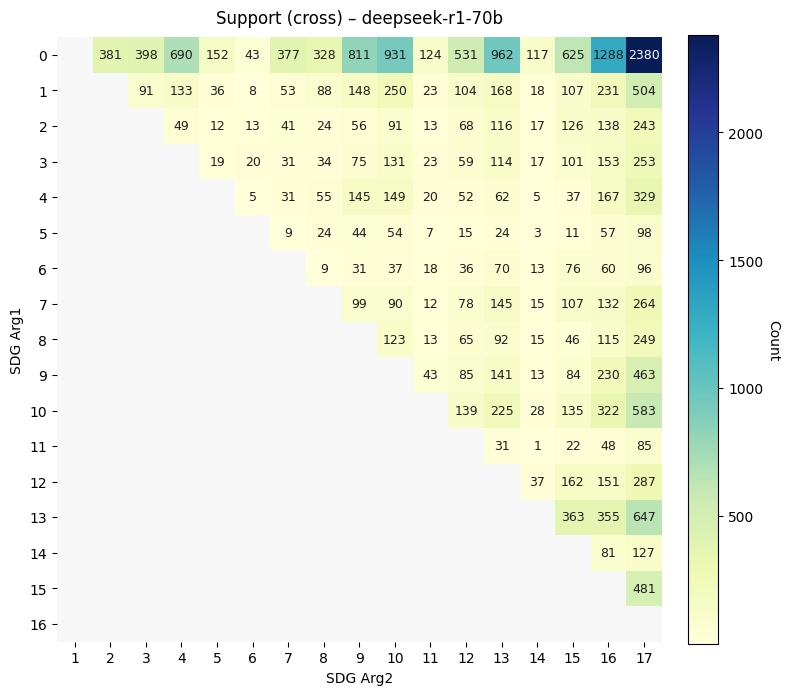

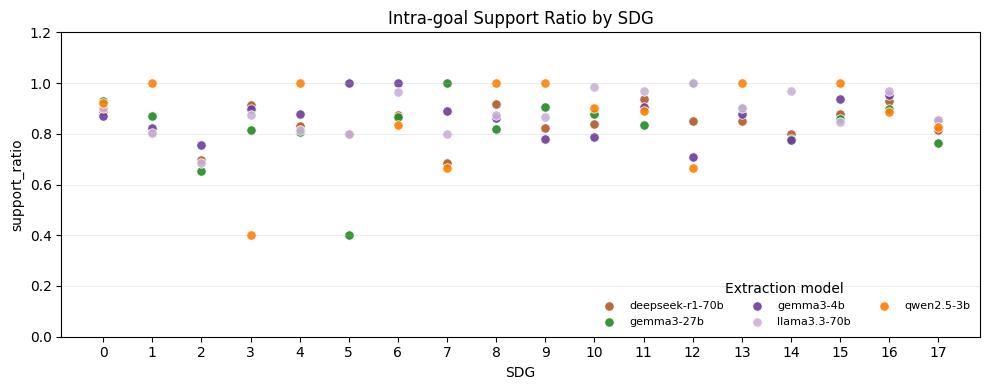

In [79]:
input_dir_allrels = r"..\\Data\\Relationships Keywords"
cross_files = [
    "cross_goalGLOBAL_SGD2023_deepseek-r1-70b.csv",
    "cross_goalGLOBAL_SGD2023_gemma3-4b.csv",
    "cross_goalGLOBAL_SGD2023_gemma3-27b.csv",
    "cross_goalGLOBAL_SGD2023_llama3.3-70b.csv",
    "cross_goalGLOBAL_SGD2023_qwen2.5-3b.csv",
]
intra_files = [
    "intra_goalGLOBAL_SGD2023_deepseek-r1-70b.csv",
    "intra_goalGLOBAL_SGD2023_gemma3-4b.csv",
    "intra_goalGLOBAL_SGD2023_gemma3-27b.csv",
    "intra_goalGLOBAL_SGD2023_llama3.3-70b.csv",
    "intra_goalGLOBAL_SGD2023_qwen2.5-3b.csv",
]

intra_coherence = summarize_intra(input_dir_allrels,intra_files , rel_col = 'rel_robertaL')
cross_coherence = summarize_cross(input_dir_allrels, cross_files, rel_col = 'rel_robertaL')
display(intra_coherence)
display(cross_coherence)

#Optional visuals:
heatmaps = cross_heatmap_tables(input_dir_allrels, cross_files, rel_col = 'rel_robertaL')

plot_heatmap(heatmaps["deepseek-r1-70b"]["Support"], title="Support (cross) – deepseek-r1-70b")
plot_intra_support_ratio(intra_coherence)